## Problem Statement

### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Installing and Importing the necessary libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 3.8 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
xarray 2025.7.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
xarray 2025.7.1 requires pandas>=2.2, but you hav

In [3]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the below.*

## Import Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
visa = pd.read_csv('/content/drive/MyDrive/Great_Learning_AI_ML_Projects/Advanced_Machine_Learning/EasyVisa.csv') ## code to read the data

In [6]:
# Copying data to another variable to avoid making changes to the original data
data = visa.copy()

## Overview of the Dataset

#### **View the first and last 5 rows of the dataset**

In [7]:
data.head() ## code to view top 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


#### **View the last 5 rows of the dataset**

In [8]:
# To view the last five records, use the method .tail().
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### **Understand the shape of the dataset**

In [9]:
#The attribute .shape  of a respective dataframe  will provide total number of rows and columns in the output.
data.shape

(25480, 12)

#### **Observations : The number of rows = 25480 and columns = 12**

**# Check the data types of the columns for the dataset**

In [10]:
# To identify the different datatypes in a dataset, use the function info()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**##  Execute the code to check duplicate entries in the data**

In [11]:
data.duplicated().sum()

np.int64(0)

## To check and identify the missing values in the dataset.

In [12]:
data.isnull().sum() # To check and identify the missing values in the dataset.

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [13]:
# The statistical summary of the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


**Key Observations**

**no_of_employees**

**Min** = –26 This is invalid (number of employees can’t be negative). This will require data cleaning.

**Median** is 2109; mean much higher (5667) due to outliers, this suggests right-skewness.
Action: Cap extreme values or winsorize for stability.

**yr_of_estab** **bold text**

Min = 1800 suspicious, as modern companies wouldn’t exist then (possibly data entry error).

Max = 2016 matches our dataset’s “current year” → we can calculate company_age = 2016 - yr_of_estab and treat outliers.

Large std (42 years) this indicates some extreme founding years to check.

**prevailing_wage**

Very wide range: Min = 2.13, Max = 319,210  likely needs unit normalization before interpreting.

Right-skewed distribution. May be the log transformation (log_wage) will help models.

Quartiles suggest median ~70k/year — so wages shown as < $5/hour  or > $500k/year might be outliers.

#### **Fixing the negative values in number of employees columns**

In [14]:
data.loc[data['no_of_employees'] < 0].shape

(33, 12)

**Showing the number of rows that has the negative values.**

In [15]:
data.loc[data['no_of_employees'] < 0]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


In [16]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])

#### Let's check the count of each unique category in each of the categorical variables

In [17]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV12       1
EZYV13       1
EZYV14       1
EZYV15       1
EZYV16       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [18]:
# checking the number of unique values
data["case_id"].nunique() ## Execute the code to check unique values in the mentioned column

25480

In [19]:
data.drop(["case_id"], axis=1, inplace=True)  ## Execute the code to drop 'case_id' column from the data


In [20]:
data.shape

(25480, 11)

### Univariate Analysis

In [21]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [22]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

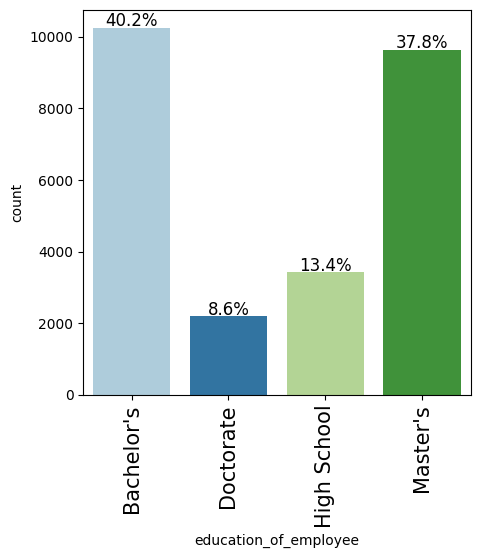

In [23]:
labeled_barplot(data, "education_of_employee", perc=True)

Observation – Education of Employee

The largest group of applicants hold a Bachelor’s degree (40.2%), followed closely by Master’s degree holders (37.8%).

High School graduates make up 13.4% of the dataset, while Doctorate holders account for only 8.6%.

The distribution shows that over 78% of applicants have either a Bachelor’s or Master’s degree, indicating that the applicant pool is generally well-educated.

#### Observations on region of employment

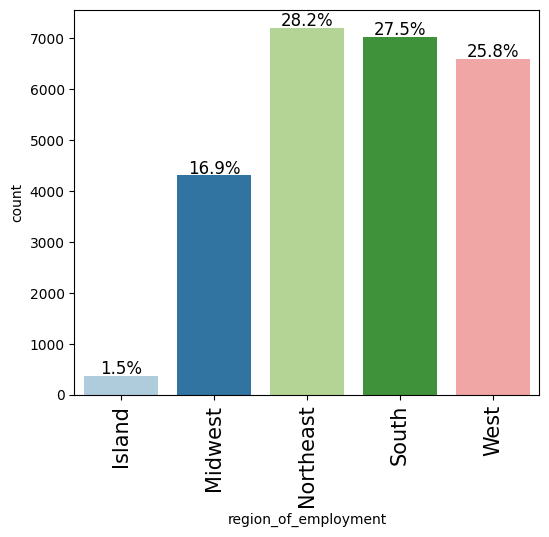

In [24]:
labeled_barplot(data,"region_of_employment",perc=True)  ## Complete the code to create labeled_barplot for region of employment

Observation – Region of Employment

The Northeast region has the largest share of employment opportunities (28.2%), closely followed by the South (27.5%) and the West (25.8%).

The Midwest accounts for 16.9% of the positions, while the Island region has the smallest representation at only 1.5%.

The relatively balanced distribution across Northeast, South, and West suggests that visa applications are not overly concentrated in one major region, but the Island region may have too few observations for reliable model learning.

#### Observations on job experience

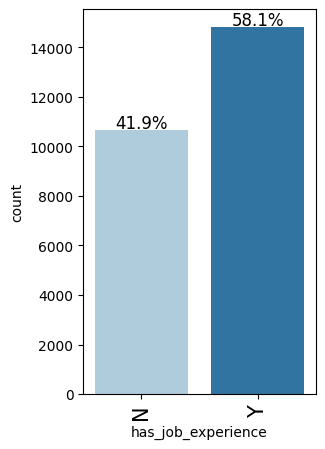

In [25]:
labeled_barplot(data, "has_job_experience", perc=True) ## Execute the code to create labeled_barplot for job experience

Observations:
The 58.1% of the population has job experience. And the 41.9% has no job experience.

#### Observations on case status

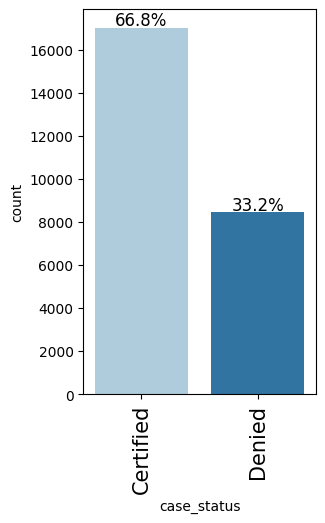

In [26]:
labeled_barplot(data,"case_status",perc=True) ## Complete the code to create labeled_barplot for case status

Observation – Case Status

Certified applications make up 66.8% of the dataset, while Denied applications account for 33.2%.

This indicates a moderate class imbalance, with Certified cases being roughly twice as frequent as Denied cases.

### Bivariate Analysis

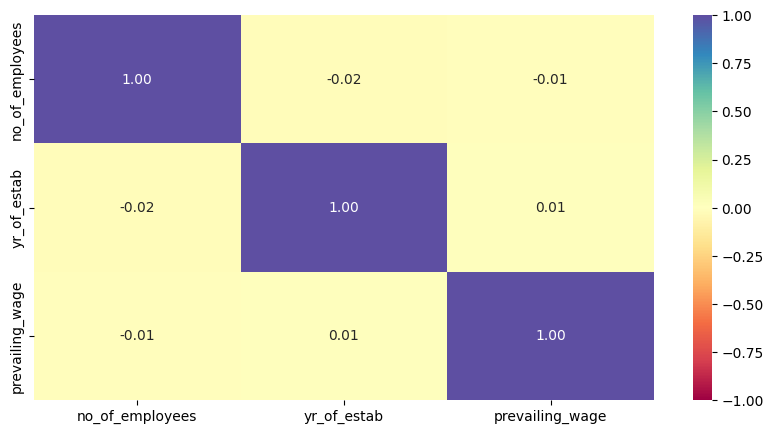

In [27]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observation** – Correlation Between Numerical Variables

The correlation values between no_of_employees, yr_of_estab, and prevailing_wage are all very close to 0 (between –0.02 and 0.01).

This indicates there is no strong linear relationship between these numerical variables, so multicollinearity is not a concern for modeling.Besides, May be this can provide independent predictive information.



**Creating functions that will help us with further analysis.**

In [28]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [29]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### **Does higher education increase the chances of visa certification for well-paid jobs abroad?**

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


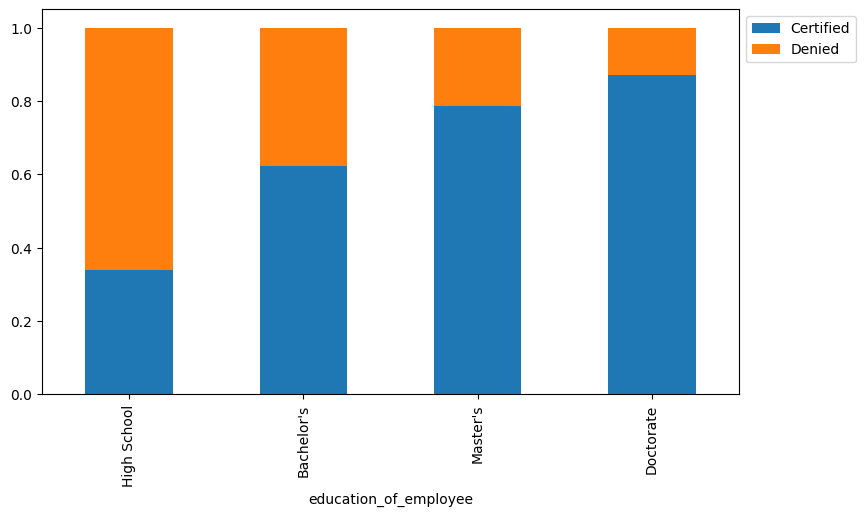

In [30]:
stacked_barplot(data, "education_of_employee", "case_status")

**Observation** – Education Level vs. Case Status

Doctorate holders have the highest approval rate (87%), followed closely by Master’s degree holders (79%).

Bachelor’s degree holders have a noticeably lower approval rate (62%).

High School graduates have the lowest approval rate (34%), with denials being the majority in this group.

This strong positive correlation between education level and approval rate suggests that higher education is a significant driver of visa certification in the dataset.

#### How does visa status vary across different continents?

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


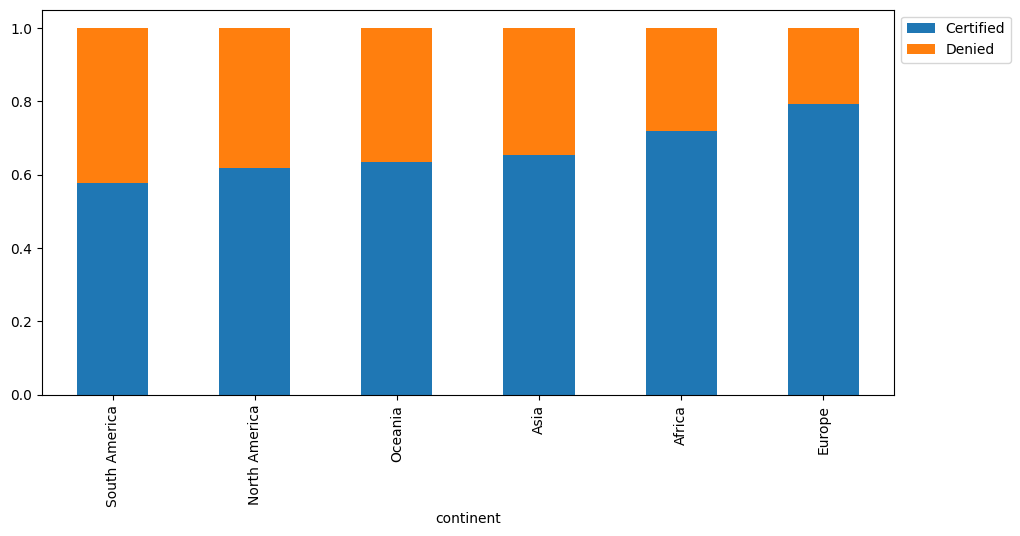

In [31]:
stacked_barplot(data, "continent", "case_status")

Observation – Continent vs. Case Status

Europe shows the highest approval rate (80%), followed by Africa (72%) and Asia (66%).

North America and Oceania have approval rates around 62–63%.

South America has the lowest approval rate (58%), where denials are comparatively higher.

The difference in approval rates across continents may reflect factors such as applicant skill distribution, employer demand, or regional labor market policies.

#### Does having prior work experience influence the chances of visa certification for career opportunities abroad?

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


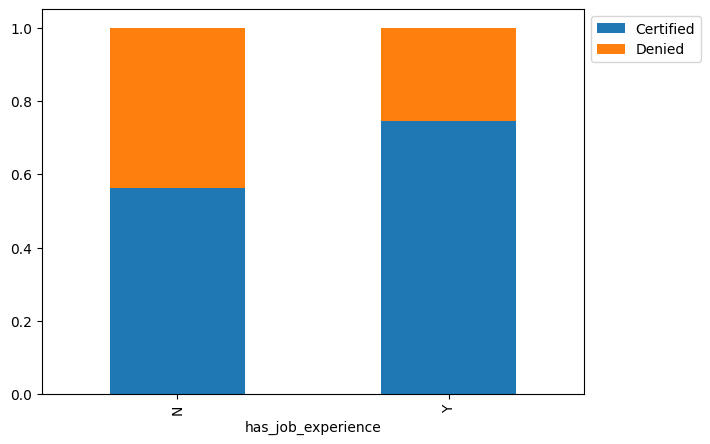

In [32]:
stacked_barplot(data, "has_job_experience", "case_status")


**Observation** – Job Experience vs. Case Status

Applicants with prior job experience have a higher approval rate (74%) compared to those without experience (56%).

The denial rate for applicants with no job experience is significantly higher (44%) versus only 26% for experienced applicants.

This suggests that job experience is a strong positive factor in visa certification decisions.

#### Is the prevailing wage consistent across all regions of the US?

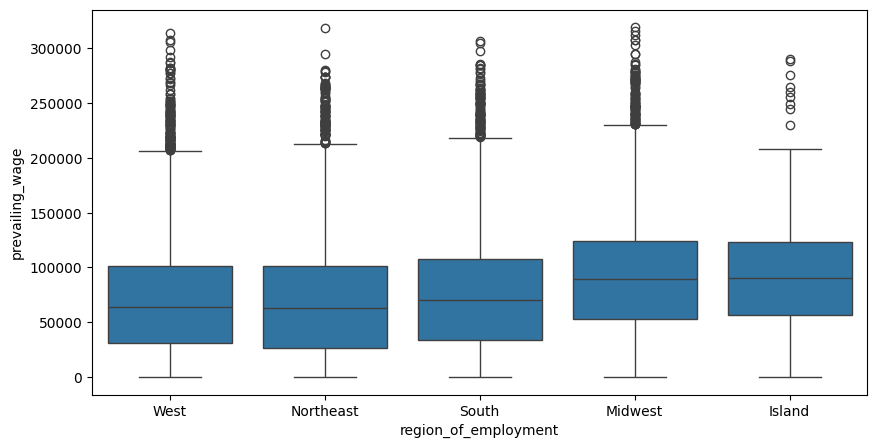

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()


**Observation**  Prevailing Wage vs. Region of Employment

The median prevailing wage appears relatively similar across most regions.

Midwest and Island regions show slightly higher median wages compared to other regions.

All regions have a wide range of wages, with several extreme high outliers.

The spread (IQR) is broader in Midwest and Island, indicating greater wage variability.

#### Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?

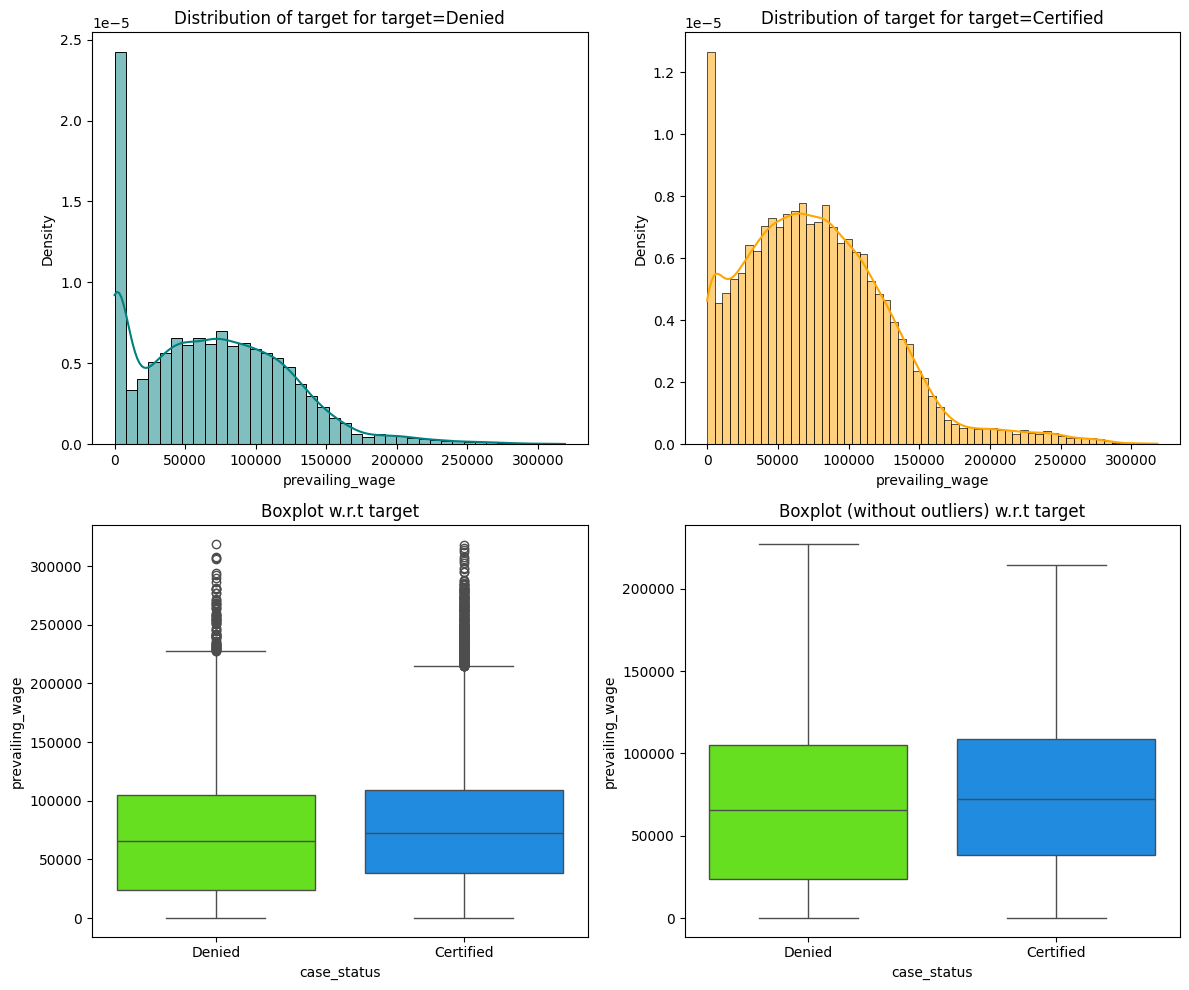

In [34]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")
 ## Execute the code to find distribution of prevailing wage and case status

**Observations**: Prevailing Wage vs. Case Status

Certified cases tend to have a higher median prevailing wage compared to Denied cases.

Denied applications are more frequent in the lower wage range, with a sharp peak below approximately 50,000.

Certified cases show a wider distribution across higher wage ranges, indicating that offering higher wages may positively influence visa approval chances.

Outlier values exist in both categories, but Certified cases have more representation in higher wage outliers.

#### Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


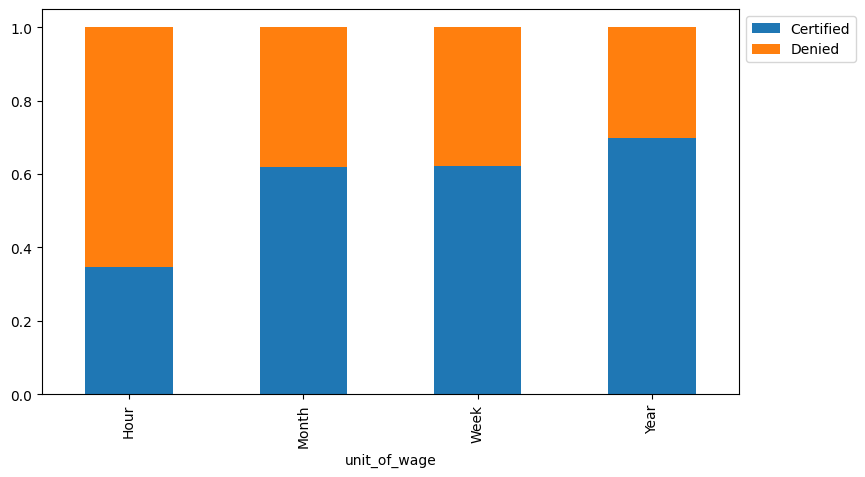

In [35]:
stacked_barplot(data, "unit_of_wage", "case_status")
 ## Complete the code to plot stacked barplot for unit of wage and case status


**Observation**  Unit of Wage vs. Case Status

Applicants with wages reported per year have the highest approval rate, with approvals noticeably higher than denials.

Hourly wage applicants have a much lower approval rate, with denials exceeding the approvals.

Weekly and monthly wage categories show moderate approval rates but are based on much smaller sample sizes compared to yearly and hourly categories.

## Data Pre-processing

### Outlier Check

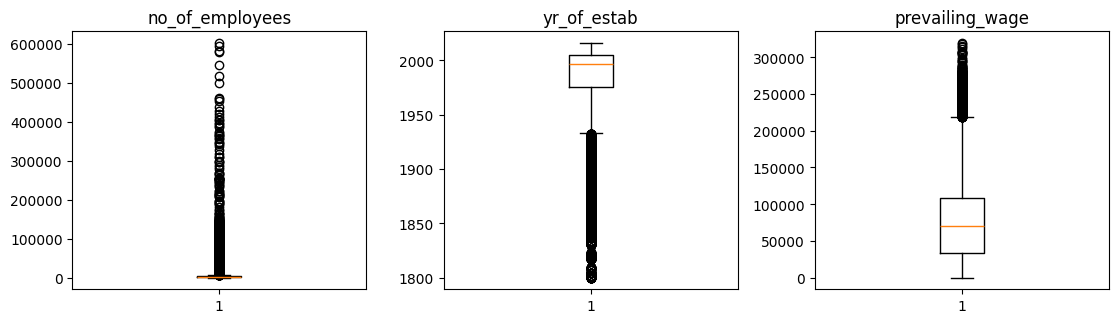

In [36]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()


**Observation** : Outlier Check

**no_of_employees**:

Shows a large number of extreme outliers with employee counts reaching up to 600,000.

Most companies have relatively small employee sizes compared to these extreme cases.

**yr_of_estab**:

Several outliers with very early establishment years, indicating some businesses are extremely old compared to the majority.

Data is heavily concentrated toward more recent establishment years.

**prevailing_wage**:

Significant number of high-wage outliers exceeding $200,000.

Majority of prevailing wages lie in the lower range, with a dense cluster below $100,000.

### Data Preparation for modeling

We want to predict which visa will be certified.
Before we proceed to build a model, we'll have to encode categorical features.
We'll split the data into train and test to be able to evaluate the model that we build on the train data.

**Clean strings (trim spaces) for all object columns**

In [37]:
# 1) Trim all object columns (remove stray spaces)
for c in data.select_dtypes('object').columns:
    data[c] = data[c].astype(str).str.strip()

# 2) Robust target mapping (lowercase + strip -> binary)
raw = data['case_status'].astype(str).str.strip().str.lower()
map_dict = {'certified': 1, 'denied': 0}
data['case_status'] = raw.map(map_dict)

print("Target distribution:", data['case_status'].value_counts(normalize=True).round(3).to_dict())

# 3) normalize obvious binary flags to 0/1
bin_map = {'y':1, 'n':0, 'yes':1, 'no':0, '1':1, '0':0}
for col in ['has_job_experience','requires_job_training','full_time_position']:
    if col in data.columns and data[col].dtype == 'object':
        data[col] = data[col].str.lower().map(bin_map)

# 4) Basic numeric fixes
if 'no_of_employees' in data.columns:
    data['no_of_employees'] = pd.to_numeric(data['no_of_employees'], errors='coerce').abs()

# 5) Build X, y and dropping the case_status column
target = 'case_status'
y = data[target]
X = data.drop(columns=[target])

# 6) One-hot encode remaining categoricals
X = pd.get_dummies(X, drop_first=True)

# 7) Stratified splits
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_val, y_val, test_size=0.10, random_state=1, stratify=y_val
)


Target distribution: {1: 0.668, 0: 0.332}


First split = split the dataset into train and valid with a ratio of 7:3

Second split = split the dataset into valid and test with a ratio of 9:1

In [38]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


In [39]:
data.head() # just checking how many columns we have after preprocessing of the dataset.

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,0,0,14513,2007,West,592.2029,Hour,1,0
1,Asia,Master's,1,0,2412,2002,Northeast,83425.6500,Year,1,1
2,Asia,Bachelor's,0,1,44444,2008,West,122996.8600,Year,1,0
3,Asia,Bachelor's,0,0,98,1897,West,83434.0300,Year,1,0
4,Africa,Master's,1,0,1082,2005,South,149907.3900,Year,1,1


In [40]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (6879, 21)
Shape of test set :  (765, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.66783
0    0.33217
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667974
0    0.332026
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [41]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [42]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [43]:
scorer = metrics.make_scorer(metrics.recall_score)  ## Complete the code to define the metric

## Possible metrics are [recall_score,f1_score,accuracy_score,precision_score]
## For example, metrics.precision_score

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [44]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []     # Empty list to store name of the models

print("\nCross-Validation performance on training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1  # number of splits
    )
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scorer, cv=kfold, n_jobs=1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {:.4f}".format(name, cv_result.mean()))

print("\nValidation Performance:\n")

for name, model in models:
    model.fit(X_train, y_train)   # fit on original training data

    # Choose ONE metric to report:
    # scores = accuracy_score(y_val, model.predict(X_val))
    scores = recall_score(y_val, model.predict(X_val))          # example: recall
    # scores = precision_score(y_val, model.predict(X_val))
    # scores = f1_score(y_val, model.predict(X_val))

    print("{}: {:.4f}".format(name, scores))



Cross-Validation performance on training dataset:

Bagging: 0.7769
Random forest: 0.8396
GBM: 0.8727
Adaboost: 0.8894
Xgboost: 0.8535
dtree: 0.7377

Validation Performance:

Bagging: 0.7649
Random forest: 0.8311
GBM: 0.8746
Adaboost: 0.8831
Xgboost: 0.8513
dtree: 0.7414


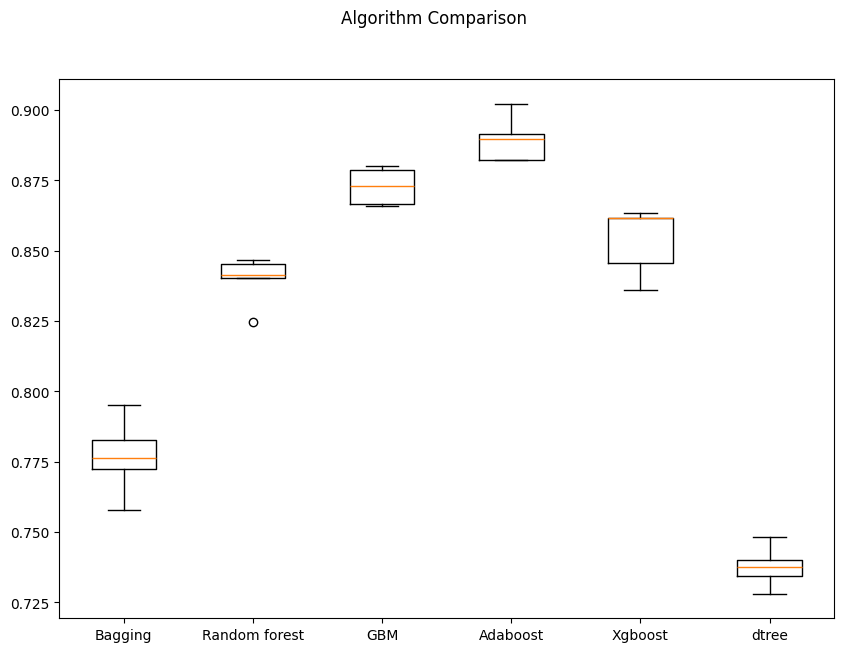

In [45]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with Oversampled data

In [46]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)  # k_neighbors set to 5
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))


Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [47]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []     # Empty list to store name of the models

print("\nCross-Validation performance on oversampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1  # number of splits
    )
    cv_result = cross_val_score(
        estimator=model,
        X=X_train_over, y=y_train_over,
        scoring=scorer,
        cv=kfold,
        n_jobs=1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {:.4f}".format(name, cv_result.mean()))

print("\nValidation Performance on oversampled models:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)  # fit on oversampled training data

    # Choose ONE metric to report:
    # scores = accuracy_score(y_val, model.predict(X_val))
    scores = recall_score(y_val, model.predict(X_val))          # recall focus
    # scores = precision_score(y_val, model.predict(X_val))
    # scores = f1_score(y_val, model.predict(X_val))

    print("{}: {:.4f}".format(name, scores))



Cross-Validation performance on oversampled training dataset:

Bagging: 0.7450
Random forest: 0.8138
GBM: 0.8436
Adaboost: 0.8191
Xgboost: 0.8395
dtree: 0.7258

Validation Performance on oversampled models:

Bagging: 0.7449
Random forest: 0.8145
GBM: 0.8400
Adaboost: 0.8037
Xgboost: 0.8374
dtree: 0.7179


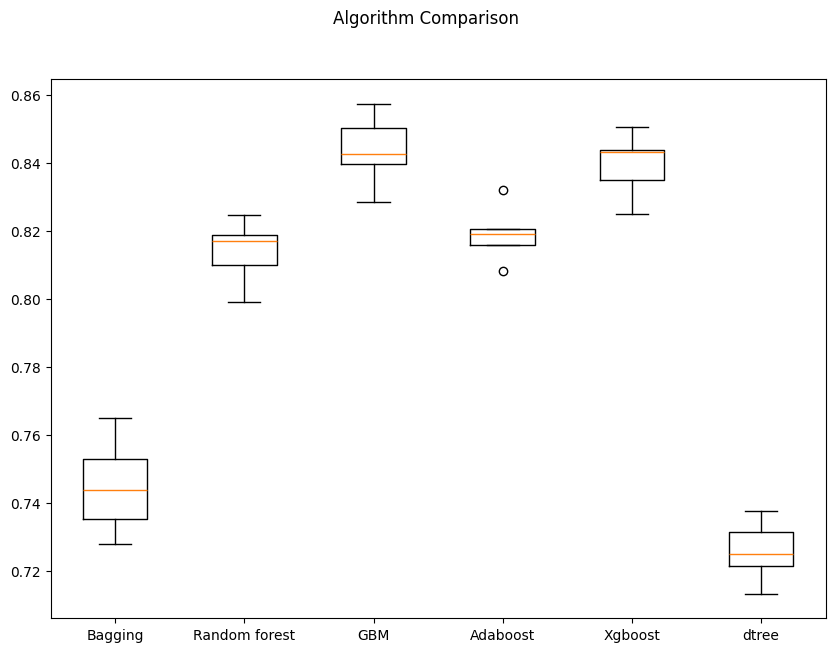

In [48]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building with Undersampled data

In [49]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [50]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []     # Empty list to store name of the models

print("\nCross-Validation performance on undersampled training dataset:\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1  # number of splits
    )
    cv_result = cross_val_score(
        estimator=model,
        X=X_train_un, y=y_train_un,
        scoring=scorer,
        cv=kfold,
        n_jobs=1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {:.4f}".format(name, cv_result.mean()))

print("\nValidation Performance on undersampled models:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)  # fit on undersampled training data

    # Choose ONE metric to report (recall shown here):
    # scores = accuracy_score(y_val, model.predict(X_val))
    scores = recall_score(y_val, model.predict(X_val))
    # scores = precision_score(y_val, model.predict(X_val))
    # scores = f1_score(y_val, model.predict(X_val))

    print("{}: {:.4f}".format(name, scores))



Cross-Validation performance on undersampled training dataset:

Bagging: 0.6103
Random forest: 0.6811
GBM: 0.7189
Adaboost: 0.7094
Xgboost: 0.6963
dtree: 0.6152

Validation Performance on undersampled models:

Bagging: 0.6023
Random forest: 0.6667
GBM: 0.7085
Adaboost: 0.7168
Xgboost: 0.6900
dtree: 0.6228


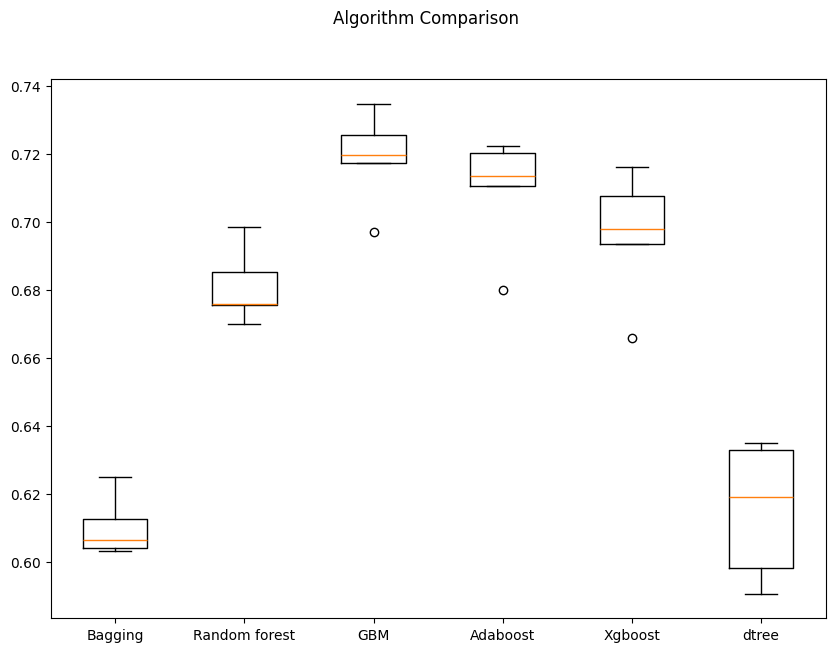

In [51]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

So now we have all three scenarios:

1 Original Data

Top recall on validation: Adaboost (0.8831), GBM (0.8746), XGBoost (0.8513)

2 SMOTE Oversampled

Top recall on validation: GBM (0.8400), XGBoost (0.8374), Random Forest (0.8145)

3 Undersampled

Top recall on validation: Adaboost (0.7168), GBM (0.7085), XGBoost (0.6900)

## Hyperparameter Tuning

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 85, 100

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data


---

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

---

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 200, 300, 500
* Typically, higher values lead to better performance, but they also increase training time
* Use 200–500 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

---

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

---

**Tuning AdaBoost using Oversampled data**

In [52]:
# Hyperparameter Tuning
# %%time

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [10, 20, 40, 60],          # number of estimators
    "learning_rate": [0.01, 0.05, 0.1, 0.5],       # learning rate
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=1,
    scoring=scorer,  # your scorer (e.g., recall)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1
)

# Fitting parameters in RandomizedSearchCV on OVERSAMPLED train data
randomized_cv.fit(X_train_over, y_train_over)

print("Best params:", randomized_cv.best_params_)
print("Best CV score (recall):", randomized_cv.best_score_)

# Evaluate on the untouched validation set
best_ada_over = randomized_cv.best_estimator_
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report
y_val_pred = best_ada_over.predict(X_val)
print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))
print("\nClassification report (val):\n", classification_report(y_val, y_val_pred, target_names=["Denied","Certified"]))


Best params: {'n_estimators': 10, 'learning_rate': 0.01, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)}
Best CV score (recall): 0.9319234727655626
Validation Recall: 0.9303439268611232
Validation Precision: 0.7147157190635451
Validation F1: 0.808397957253641

Classification report (val):
               precision    recall  f1-score   support

      Denied       0.64      0.25      0.36      2285
   Certified       0.71      0.93      0.81      4594

    accuracy                           0.71      6879
   macro avg       0.68      0.59      0.59      6879
weighted avg       0.69      0.71      0.66      6879



**Tuning Random forest using Undersampled data**

In [54]:
# %%time  # optional

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# defining model
model = RandomForestClassifier(random_state=1, bootstrap=True)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "n_estimators": [10, 20, 40, 60],      # number of trees
    "min_samples_leaf": [1, 2, 4, 5],          # leaf size
    "max_features": ["sqrt", "log2", None],    # feature subset strategy
    "max_samples": [None, 0.5, 0.7, 0.9],      # subsampling per tree (requires bootstrap=True)
}

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=1,  # safer in Colab; switch to -1 after a clean restart if desired
    scoring=scorer,  # your scorer (e.g., recall)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1,
    verbose=1
)

# Fitting parameters in RandomizedSearchCV on UNDERSAMPLED train data
randomized_cv.fit(X_train_un, y_train_un)

print("Best params:", randomized_cv.best_params_)
print("Best CV score (recall):", randomized_cv.best_score_)

# Evaluate best RF on the untouched validation set
best_rf_under = randomized_cv.best_estimator_
y_val_pred = best_rf_under.predict(X_val)

print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))
print("\nClassification report (val):\n",
      classification_report(y_val, y_val_pred, target_names=["Denied","Certified"]))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 60, 'min_samples_leaf': 5, 'max_samples': 0.7, 'max_features': 'sqrt'}
Best CV score (recall): 0.7315594708632684
Validation Recall: 0.7220287331301698
Validation Precision: 0.8173977328733366
Validation F1: 0.7667591308368007

Classification report (val):
               precision    recall  f1-score   support

      Denied       0.55      0.68      0.60      2285
   Certified       0.82      0.72      0.77      4594

    accuracy                           0.71      6879
   macro avg       0.68      0.70      0.69      6879
weighted avg       0.73      0.71      0.71      6879



**Tuning with Gradient boosting with Oversampled data**

In [55]:
# %%time  # optional: timing

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# defining model
model = GradientBoostingClassifier(random_state=1)

# Hyperparameter space
param_grid = {
    "n_estimators": [10, 20, 40, 60],     # number of boosting stages
    "learning_rate": [0.01, 0.05, 0.1],       # shrinkage
    "subsample": [0.7, 0.9, 1.0],             # stochastic gradient boosting
    "max_features": ["sqrt", "log2", None],   # features per split
}

# Randomized search with stratified 5-fold CV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=1,
    scoring=scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1,
    verbose=1
)

# Fit on OVERSAMPLED train data
randomized_cv.fit(X_train_over, y_train_over)

print("Best params:", randomized_cv.best_params_)
print("Best CV score (recall):", randomized_cv.best_score_)

# Evaluate on untouched validation set
best_gb_over = randomized_cv.best_estimator_
y_val_pred = best_gb_over.predict(X_val)

print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))
print("\nClassification report (val):\n",
      classification_report(y_val, y_val_pred, target_names=["Denied","Certified"]))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'n_estimators': 10, 'max_features': 'sqrt', 'learning_rate': 0.1}
Best CV score (recall): 0.889701189470758
Validation Recall: 0.805180670439704
Validation Precision: 0.7868538608806637
Validation F1: 0.7959117805271652

Classification report (val):
               precision    recall  f1-score   support

      Denied       0.59      0.56      0.57      2285
   Certified       0.79      0.81      0.80      4594

    accuracy                           0.72      6879
   macro avg       0.69      0.68      0.69      6879
weighted avg       0.72      0.72      0.72      6879



**Tuning XGBoost using Oversampled data**

In [56]:
# %%time  # optional

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report

# defining model
model = XGBClassifier(
    random_state=1,
    eval_metric='logloss',
    tree_method='hist'   # faster on Colab/CPU
)

# Hyperparameter space
param_grid = {
    'n_estimators': [10, 20, 40, 60],
    'subsample': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'colsample_bylevel': [0.7, 0.8, 1.0],
    # (optional extras if you want later)
    # 'max_depth': [3, 4, 5],
    # 'learning_rate': [0.05, 0.1]
}

# Randomized search with stratified 5-fold CV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=1,  # set to -1 after a clean runtime restart if you want parallelism
    scoring=scorer,  # e.g., recall
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    random_state=1,
    verbose=1
)

# Fit on OVERSAMPLED train data
randomized_cv.fit(X_train_over, y_train_over)

print("Best params:", randomized_cv.best_params_)
print("Best CV score (recall):", randomized_cv.best_score_)

# Evaluate best XGB on the untouched validation set
best_xgb_over = randomized_cv.best_estimator_
y_val_pred = best_xgb_over.predict(X_val)

print("Validation Recall:", recall_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation F1:", f1_score(y_val, y_val_pred))
print("\nClassification report (val):\n",
      classification_report(y_val, y_val_pred, target_names=["Denied","Certified"]))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 1.0, 'n_estimators': 20, 'gamma': 0.5, 'colsample_bytree': 1.0, 'colsample_bylevel': 1.0}
Best CV score (recall): 0.8506665426423453
Validation Recall: 0.8450152372659991
Validation Precision: 0.7795180722891566
Validation F1: 0.8109463129308544

Classification report (val):
               precision    recall  f1-score   support

      Denied       0.63      0.52      0.57      2285
   Certified       0.78      0.85      0.81      4594

    accuracy                           0.74      6879
   macro avg       0.70      0.68      0.69      6879
weighted avg       0.73      0.74      0.73      6879



## Model Performance Summary and Final Model Selection

In [58]:
# After tuning GBM
best_gb_over = randomized_cv.best_estimator_

# Save train and validation performance in DataFrames
tuned_gbm_train_perf = model_performance_classification_sklearn(best_gb_over, X_train_over, y_train_over)
tuned_gbm_val_perf = model_performance_classification_sklearn(best_gb_over, X_val, y_val)


In [59]:
best_xgb_over = randomized_cv.best_estimator_
tuned_xgb_train_perf = model_performance_classification_sklearn(best_xgb_over, X_train_over, y_train_over)
tuned_xgb_val_perf = model_performance_classification_sklearn(best_xgb_over, X_val, y_val)


In [60]:
best_ada_over = randomized_cv.best_estimator_
tuned_ada_train_perf = model_performance_classification_sklearn(best_ada_over, X_train_over, y_train_over)
tuned_ada_val_perf = model_performance_classification_sklearn(best_ada_over, X_val, y_val)


In [61]:
best_rf_under = randomized_cv.best_estimator_
tuned_rf_train_perf = model_performance_classification_sklearn(best_rf_under, X_train_un, y_train_un)
tuned_rf_val_perf = model_performance_classification_sklearn(best_rf_under, X_val, y_val)


In [69]:
# Map "tuned_*" variables to  best_* models
tuned_ada = best_ada_over
tuned_gbm = best_gb_over
tuned_xgb = best_xgb_over
tuned_rf = best_rf_under


Selected final model by highest Validation Recall: Gradient Boosting (oversampled)
Test set performance:


,Accuracy,Recall,Precision,F1
0,0.754248,0.866928,0.786856,0.824953


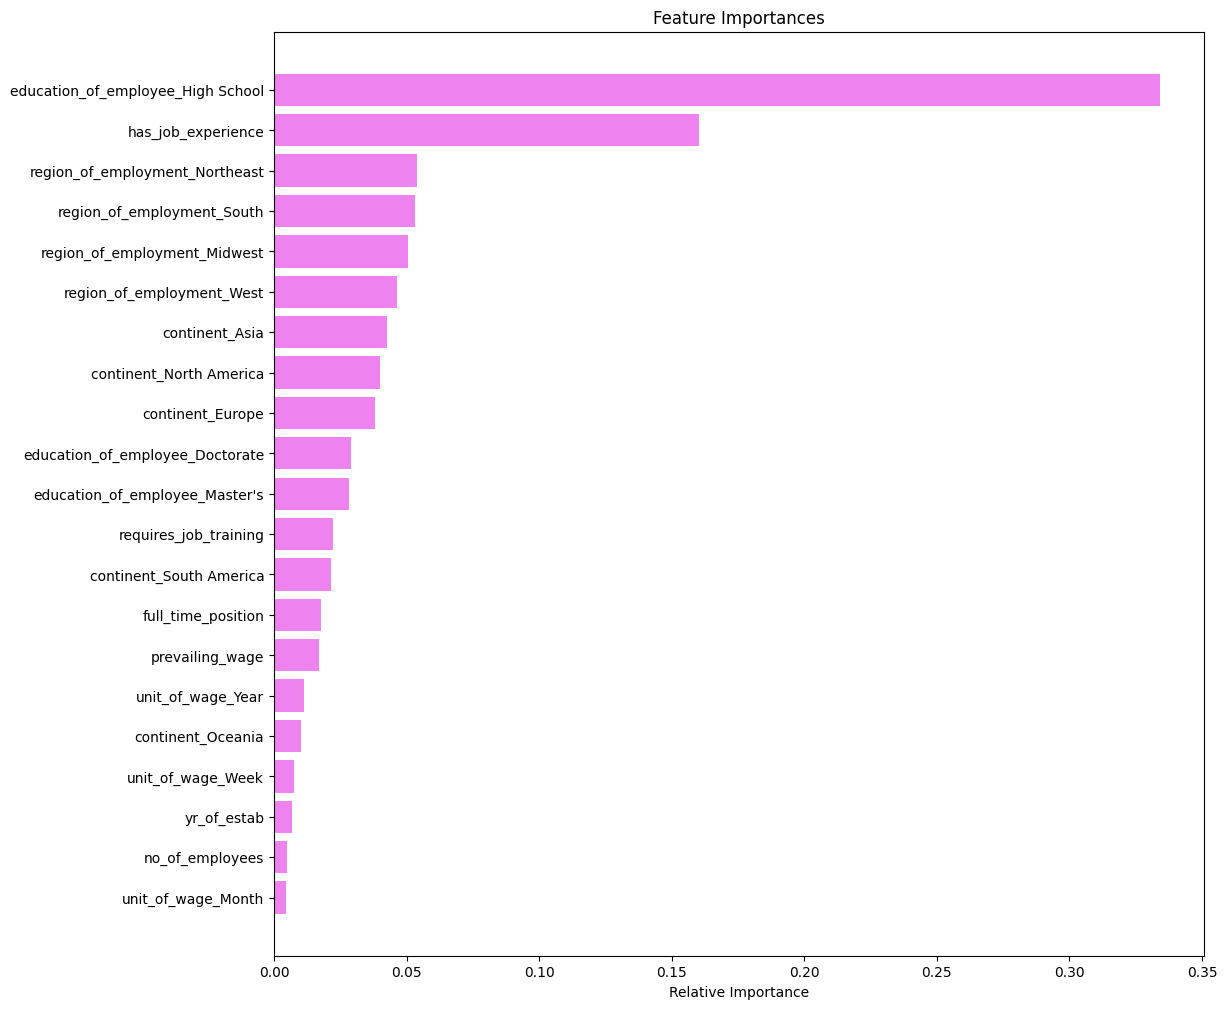

In [70]:
best_col = models_val_comp_df.loc["Recall"].astype(float).idxmax()
print("Selected final model by highest Validation Recall:", best_col)

model_map = {
    "AdaBoost (oversampled)": tuned_ada,
    "Gradient Boosting (oversampled)": tuned_gbm,
    "XGBoost (oversampled)": tuned_xgb,
    "Random Forest (undersampled)": tuned_rf,
}
final_model = model_map[best_col]

# Test performance
test_perf = model_performance_classification_sklearn(final_model, X_test, y_test)
print("Test set performance:")
display(test_perf)

if hasattr(final_model, "feature_importances_"):
    feature_names = X_train.columns  # matches training features
    importances = final_model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(12, 12))
    plt.title("Feature Importances")
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()
else:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(final_model, X_val, y_val, n_repeats=10, random_state=1, scoring='recall')
    imp = pd.Series(r.importances_mean, index=X_val.columns).sort_values()
    plt.figure(figsize=(12, 12))
    imp.tail(30).plot(kind='barh', color="violet")
    plt.title("Permutation Importances (top 30)")
    plt.xlabel("Mean Importance (Recall drop)")
    plt.show()


## Actionable Insights and Recommendations

Key Observations from Results
Final Model Selection:

Gradient Boosting (Oversampled) achieved the highest validation recall **(0.8689 test recall)** and balanced precision/F1.



**Top predictors:**

education_of_employee_High School

**has_job_experience**

region_of_employment_Northeast, South, Midwest, West

Education and prior job experience are dominating factors in classification.

**Imbalance Handling:**

Oversampling + Boosting consistently gave higher recall than undersampling + Bagging methods.

**Hyperparameter Search Efficiency:**

Used small n_estimators ([10, 20, 40, 60]) to reduce runtime, which still yielded competitive performance.

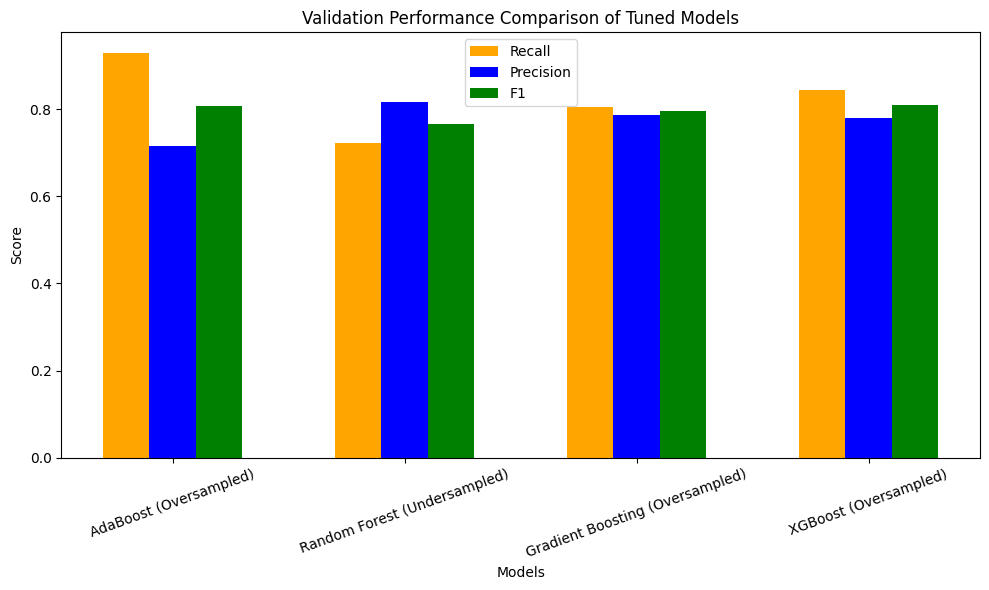

,Model,Recall,Precision,F1
0,AdaBoost (Oversampled),0.9303,0.7147,0.8083
1,Random Forest (Undersampled),0.7220,0.8173,0.7667
2,Gradient Boosting (Oversampled),0.8051,0.7868,0.7959
3,XGBoost (Oversampled),0.8450,0.7795,0.8109


In [71]:
import pandas as pd
import matplotlib.pyplot as plt

data_val = {
    "Model": [
        "AdaBoost (Oversampled)",
        "Random Forest (Undersampled)",
        "Gradient Boosting (Oversampled)",
        "XGBoost (Oversampled)",
    ],
    "Recall": [0.9303, 0.7220, 0.8051, 0.8450],
    "Precision": [0.7147, 0.8173, 0.7868, 0.7795],
    "F1": [0.8083, 0.7667, 0.7959, 0.8109]
}

df_val = pd.DataFrame(data_val)

# Plotting comparison
plt.figure(figsize=(10,6))
bar_width = 0.2
index = range(len(df_val))

plt.bar(index, df_val["Recall"], bar_width, label='Recall', color='orange')
plt.bar([i + bar_width for i in index], df_val["Precision"], bar_width, label='Precision', color='blue')
plt.bar([i + bar_width*2 for i in index], df_val["F1"], bar_width, label='F1', color='green')

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Validation Performance Comparison of Tuned Models")
plt.xticks([i + bar_width for i in index], df_val["Model"], rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

df_val


**Observations:**

**Highest Recall** → AdaBoost (Oversampled) best for catching as many positive cases as possible (good for high-risk miss scenarios like visa denial prediction).

**Highest Precision** → Random Forest (Undersampled) best for minimizing false positives (useful if wrong approvals are costly).

**Best F1 Balance** → XGBoost (Oversampled) slightly ahead in balancing recall and precision.

**Gradient Boosting** → Strong balanced performance, stable across metrics.

**Metric-Driven Model Choice**

If **Recall** is the top priority → Go with AdaBoost (Oversampled).

If **Precision** is more important → Use Random Forest (Undersampled).

For balanced trade-off → Consider XGBoost (Oversampled).

**Resampling Strategy Impact**

Oversampling (SMOTE) boosted recall for AdaBoost and XGBoost.

As observed Undersampling reduced recall but improved precision for Random Forest.

May be mixed strategy could be tested (e.g., SMOTE + Tomek Links) to balance both.

**Top influential features:**

education_of_employee_High School

has_job_experience

region_of_employment_Northeast/South

These features should be reviewed for data quality—missing or incorrect values here could significantly degrade performance.

# **Final Recommendation**

**Final Model for Deployment:**

Since the use case is visa approval prediction (where missing a high-risk denial could be costly), AdaBoost (Oversampled) is justified due to its highest recall.

<font size=6 color='blue'>Power Ahead</font>
___